## 3.Data cleaning ##

In [ ]:


# -------------------------------------------------
# STEP 1: Import Libraries
# -------------------------------------------------
import pandas as pd
import numpy as np

# -------------------------------------------------
# STEP 2: Load Dataset
# -------------------------------------------------
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Original Dataset")
print(data.head())

# -------------------------------------------------
# STEP 3: Remove Duplicate Rows
# -------------------------------------------------
data = data.drop_duplicates()

# -------------------------------------------------
# STEP 4: Remove Missing Values
# -------------------------------------------------
data = data.dropna()

# -------------------------------------------------
# STEP 5: Convert Date Format
# -------------------------------------------------
data['published_at'] = pd.to_datetime(data['published_at'])

# -------------------------------------------------
# STEP 6: Reset Index
# -------------------------------------------------
data = data.reset_index(drop=True)

print("Cleaned Dataset")
print(data.head())



Original Dataset
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  
Cleaned Dataset
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Beh

## 4.Exploratory Data Analysis (EDA) ##

Videos per Channel
channel
Mikey No Code              3
Jeff Su                    2
Futurepedia                2
Dan Martell                1
AI Master                  1
WebKnower                  1
edureka!                   1
Simplilearn                1
theMITmonk                 1
Kevin Stratvert            1
Kellan Henneberry          1
Ed Hill | AI Automation    1
AI Alfie                   1
Moritz | AI Builder        1
Roboverse                  1
freeCodeCamp.org           1
Name: count, dtype: int64


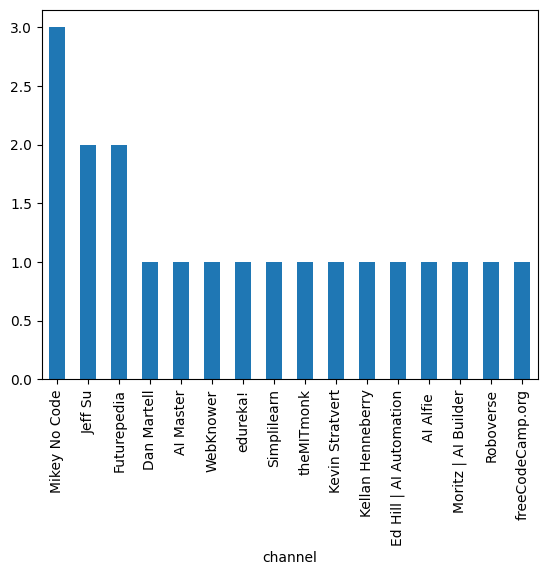

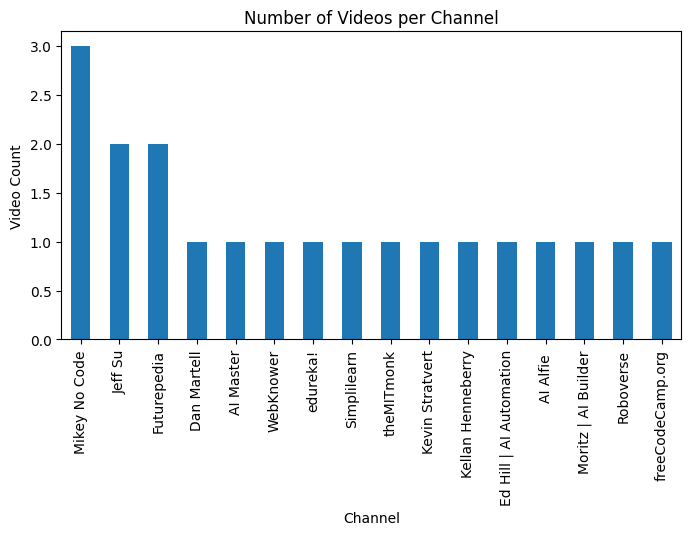

2026-03-12 19:02:24.272 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-12 19:02:24.329 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


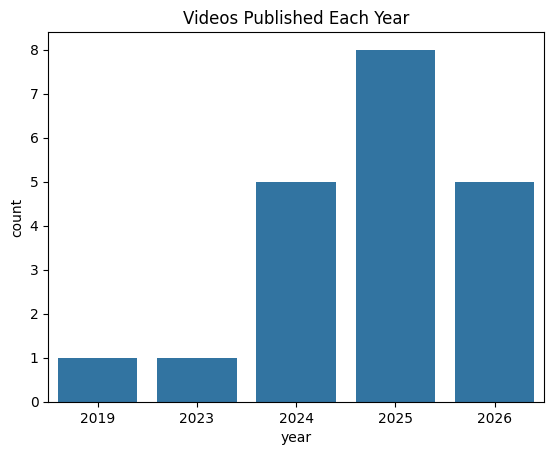

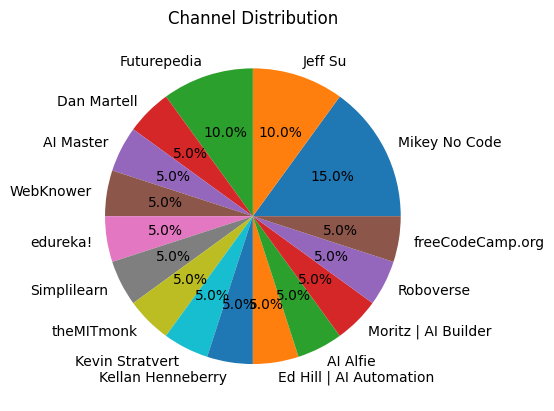

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
channel_count = data['channel'].value_counts()

print("Videos per Channel")
print(channel_count)
channel_count.plot(kind='bar')

# -------------------------------------------------
# GRAPH 1: Videos per Channel
# -------------------------------------------------
plt.figure(figsize=(8,4))

data['channel'].value_counts().plot(kind='bar')

plt.title("Number of Videos per Channel")
plt.xlabel("Channel")
plt.ylabel("Video Count")

plt.show()

# -------------------------------------------------
# GRAPH 2: Videos Published per Year
# -------------------------------------------------
data['published_at'] = pd.to_datetime(data['published_at'])

data['year'] = data['published_at'].dt.year

sns.countplot(x='year', data=data)

plt.title("Videos Published Each Year")
plt.show()

# -------------------------------------------------
# GRAPH 3: Channel Distribution Pie Chart
# -------------------------------------------------
data['channel'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Channel Distribution")
plt.show()


## 5.Content-Based Social Media Analysis (Topic Analysis) ##

{'ai': 20, 'to': 11, 'how': 10, 'for': 8, 'beginners': 7, 'tutorial': 6, 'build': 5, 'course': 5, 'a': 5, '|': 5}


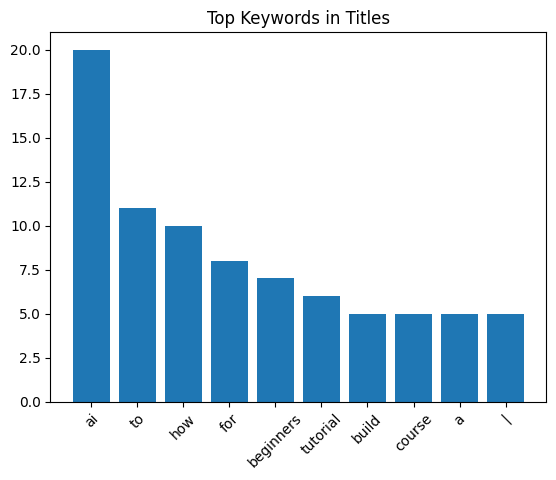

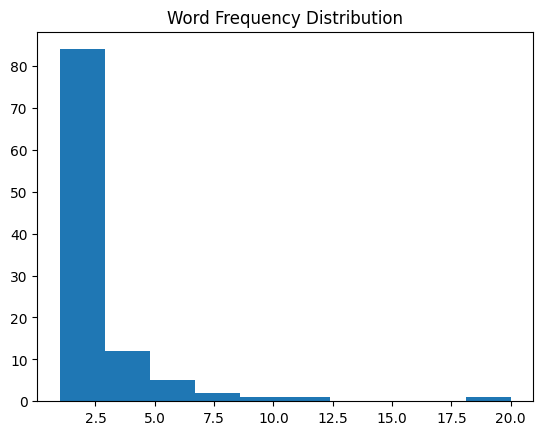

In [ ]:
from collections import Counter

# -------------------------------------------------
# STEP 3: Extract Words
# -------------------------------------------------
text = " ".join(data['title']).lower()

words = text.split()

# -------------------------------------------------
# STEP 4: Word Frequency
# -------------------------------------------------
word_freq = Counter(words)

top_words = dict(word_freq.most_common(10))

print(top_words)

# -------------------------------------------------
# GRAPH 1: Top Keywords
# -------------------------------------------------
plt.bar(top_words.keys(), top_words.values())

plt.title("Top Keywords in Titles")
plt.xticks(rotation=45)

plt.show()

# -------------------------------------------------
# GRAPH 2: Word Frequency Histogram
# -------------------------------------------------
plt.hist(list(word_freq.values()), bins=10)

plt.title("Word Frequency Distribution")

plt.show()


## 6.Structure Based Analysis (Network) ##

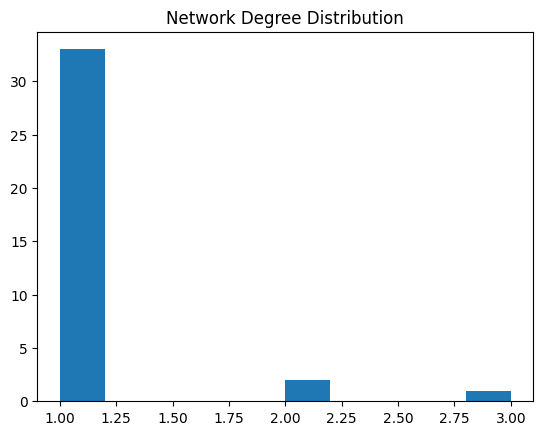

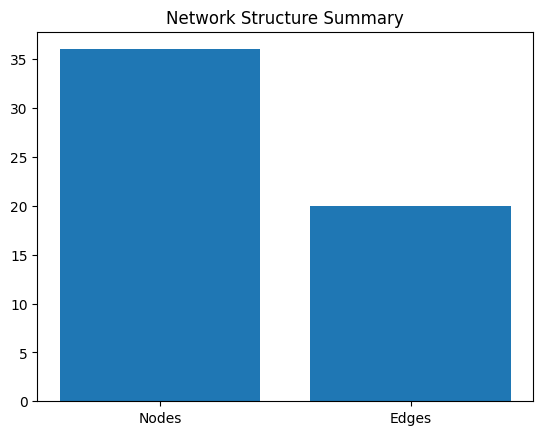

In [22]:
import networkx as nx
# -------------------------------------------------
# STEP 1: Create Graph
# -------------------------------------------------
G = nx.Graph()

for i,row in data.iterrows():
    G.add_edge(row['channel'], row['title'])

 

# -------------------------------------------------
# GRAPH 1: Degree Distribution
# -------------------------------------------------
degree = [G.degree(n) for n in G.nodes()]

plt.hist(degree)

plt.title("Network Degree Distribution")

plt.show()

# -------------------------------------------------
# GRAPH 2: Node Count
# -------------------------------------------------
plt.bar(["Nodes","Edges"],[G.number_of_nodes(),G.number_of_edges()])

plt.title("Network Structure Summary")

plt.show()

## 7.Dashboard using Streamlit ##

## 8.Creative Campaign Design for Social Media Promotion ##

Top Campaign Keywords
{'ai': 20, 'to': 11, 'how': 10, 'for': 8, 'beginners': 7, 'tutorial': 6, 'build': 5, 'course': 5, 'a': 5, '|': 5}


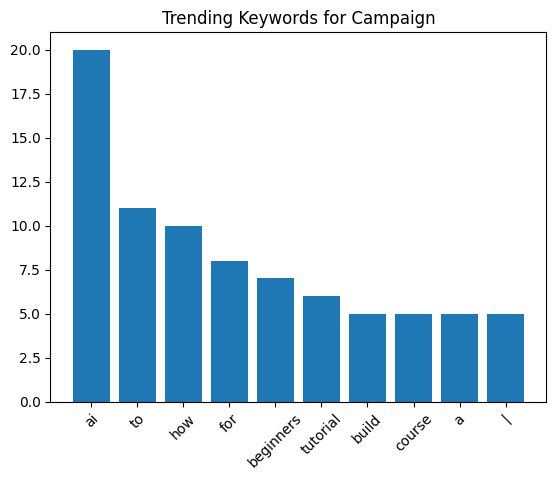

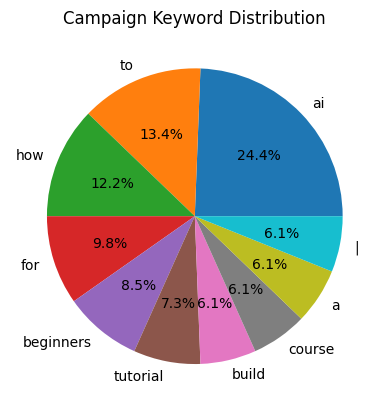

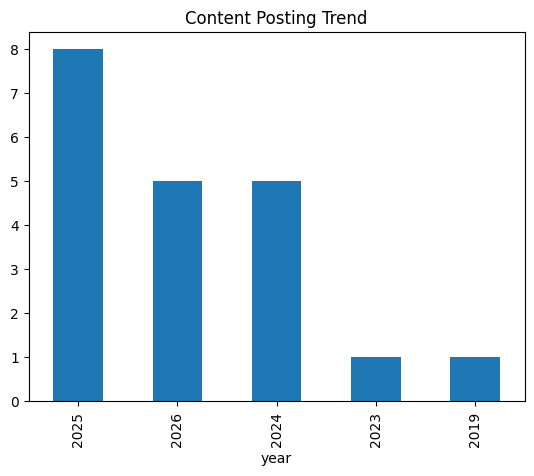

In [25]:
# -------------------------------------------------
# STEP 3: Extract Keywords from Titles
# -------------------------------------------------
text = " ".join(data['title']).lower()

words = text.split()

word_freq = Counter(words)

top_words = dict(word_freq.most_common(10))

print("Top Campaign Keywords")
print(top_words)

# -------------------------------------------------
# GRAPH 1: Top Promotion Keywords
# -------------------------------------------------
plt.bar(top_words.keys(), top_words.values())

plt.xticks(rotation=45)

plt.title("Trending Keywords for Campaign")

plt.show()

# -------------------------------------------------
# GRAPH 2: Keyword Distribution
# -------------------------------------------------
plt.pie(top_words.values(), labels=top_words.keys(), autopct='%1.1f%%')

plt.title("Campaign Keyword Distribution")

plt.show()

# -------------------------------------------------
# GRAPH 3: Video Posting Trend
# -------------------------------------------------
data['published_at'] = pd.to_datetime(data['published_at'])

data['year'] = data['published_at'].dt.year

data['year'].value_counts().plot(kind='bar')

plt.title("Content Posting Trend")

plt.show()

## 9: Competitor Activity Analysis ##

Competitor Activity
channel
Mikey No Code              3
Jeff Su                    2
Futurepedia                2
Dan Martell                1
AI Master                  1
WebKnower                  1
edureka!                   1
Simplilearn                1
theMITmonk                 1
Kevin Stratvert            1
Kellan Henneberry          1
Ed Hill | AI Automation    1
AI Alfie                   1
Moritz | AI Builder        1
Roboverse                  1
freeCodeCamp.org           1
Name: count, dtype: int64


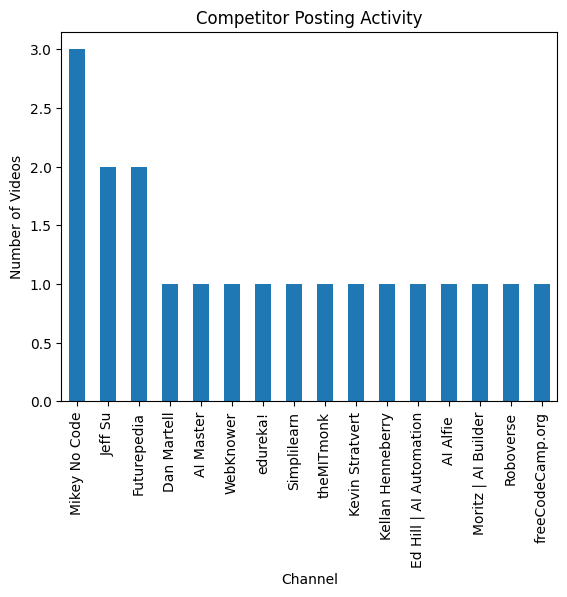

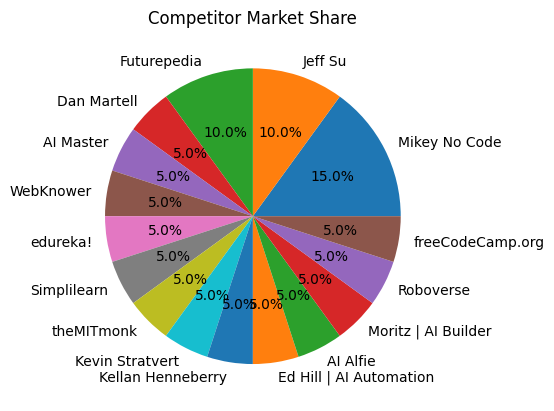

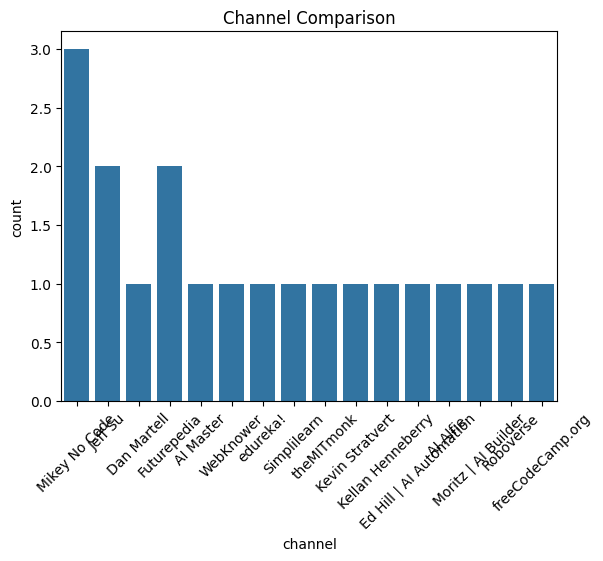

In [26]:
# -------------------------------------------------
# STEP 3: Competitor Activity
# -------------------------------------------------
competitor = data['channel'].value_counts()

print("Competitor Activity")
print(competitor)

# -------------------------------------------------
# GRAPH 1: Competitor Posting Frequency
# -------------------------------------------------
competitor.plot(kind='bar')

plt.title("Competitor Posting Activity")

plt.xlabel("Channel")

plt.ylabel("Number of Videos")

plt.show()

# -------------------------------------------------
# GRAPH 2: Competitor Market Share
# -------------------------------------------------
competitor.plot(kind='pie', autopct='%1.1f%%')

plt.title("Competitor Market Share")

plt.show()

# -------------------------------------------------
# GRAPH 3: Competitor Comparison
# -------------------------------------------------
sns.countplot(x='channel', data=data)

plt.xticks(rotation=45)

plt.title("Channel Comparison")

plt.show()

## 10: Social Media Text Analytics Model (Customer Review Analysis) ##

                                                title sentiment
0   AI Tutorial for Beginners 2026: How To Use AI ...   Neutral
1   Google’s AI Course for Beginners (in 10 minutes)!   Neutral
2   You’re not behind (yet): How to learn AI in 18...  Positive
3   You’re Not Behind (Yet): How to Learn AI in 29...  Positive
4   AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   Neutral
5   How To Create A Free App From Scratch (AI Tuto...  Positive
6   Python AI And Generative AI Course For Beginne...   Neutral
7    99% of Beginners Don&#39;t Know the Basics of AI   Neutral
8   Google AI Studio - Full Tutorial 2026: How To ...  Positive
9   You’re Not Behind (Yet): How to Build AI Agent...  Positive
10  Artificial Intelligence Full Course | Artifici...  Negative
11  AI Full Course 2025 | AI Tutorial for Beginner...  Negative
12  You’re Not Behind (Yet): How to Learn AI in 17...  Positive
13                        7 AI tools you NEED to try!   Neutral
14  how i make $36,438/mo posting YouTub

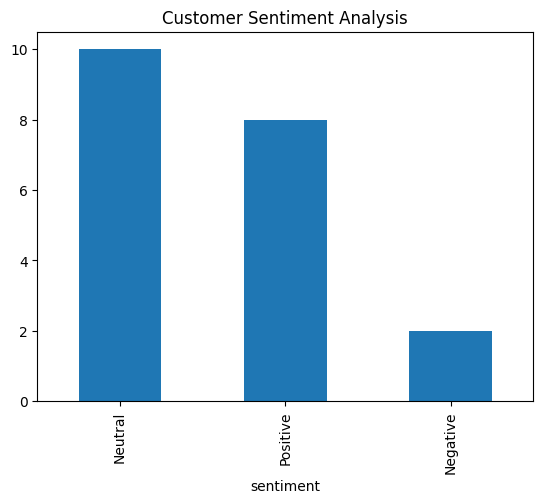

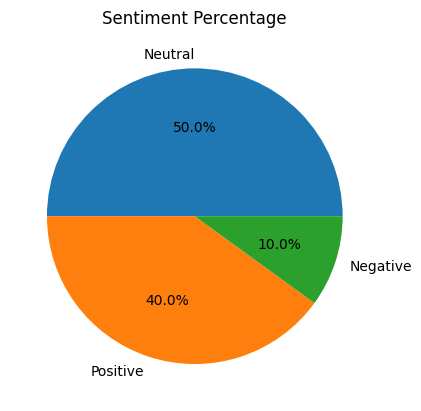

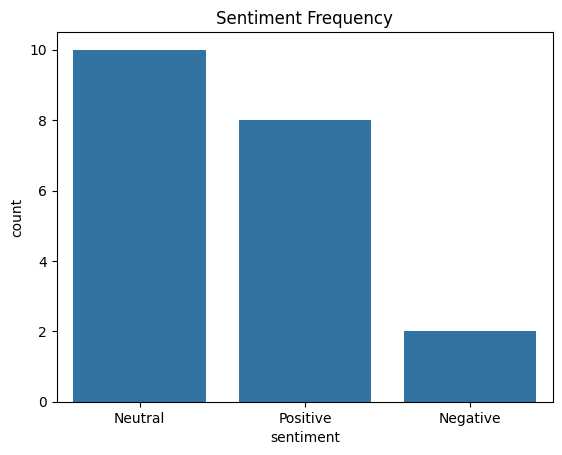

In [28]:
from textblob import TextBlob
# -------------------------------------------------
# STEP 3: Sentiment Analysis Function
# -------------------------------------------------
def sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

# -------------------------------------------------
# STEP 4: Apply Sentiment Analysis
# -------------------------------------------------
data['sentiment'] = data['title'].apply(sentiment)

print(data[['title','sentiment']])

# -------------------------------------------------
# GRAPH 1: Sentiment Distribution
# -------------------------------------------------
data['sentiment'].value_counts().plot(kind='bar')

plt.title("Customer Sentiment Analysis")

plt.show()

# -------------------------------------------------
# GRAPH 2: Sentiment Pie Chart
# -------------------------------------------------
data['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Sentiment Percentage")

plt.show()

# -------------------------------------------------
# GRAPH 3: Sentiment Count
# -------------------------------------------------
sns.countplot(x='sentiment', data=data)

plt.title("Sentiment Frequency")

plt.show()